In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, Model
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import tensorflow.keras.backend as K
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import MultiHeadAttention
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, AveragePooling1D, LSTM, BatchNormalization, Attention, Dropout, Dense, GlobalAveragePooling1D, Embedding, Reshape, Concatenate

In [2]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [3]:
df_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]
mean_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]['solarradiation'].mean()

df_13_00, mean_13_00

(                        Kwh            name  temp  feelslike   dew  humidity  \
 datetime                                                                       
 2022-01-01 13:00:00  0.4263  Kozani, Greece  14.0       14.0   3.0     47.46   
 2022-01-02 13:00:00  0.4391  Kozani, Greece  14.0       14.0   1.0     41.15   
 2022-01-03 13:00:00  0.4421  Kozani, Greece  13.0       13.0   3.0     50.65   
 2022-01-04 13:00:00  0.4611  Kozani, Greece  11.0       11.0   0.0     46.61   
 2022-01-05 13:00:00  0.4397  Kozani, Greece  14.0       14.0   2.0     44.20   
 ...                     ...             ...   ...        ...   ...       ...   
 2024-06-30 13:00:00  0.6883  Kozani, Greece  31.0       29.1   7.0     22.30   
 2024-07-01 13:00:00  0.6906  Kozani, Greece  33.9       32.2  10.6     24.14   
 2024-07-02 13:00:00  0.4582  Kozani, Greece  31.0       29.5  10.0     27.32   
 2024-07-03 13:00:00  0.7472  Kozani, Greece  25.0       25.0   9.0     36.24   
 2024-07-04 13:00:00  0.6692

In [4]:
data['solarradiation'].fillna(mean_13_00, inplace=True)

In [5]:
kwh_data = data[['temp', 'cloudcover', 'solarradiation', 'conditions']]
kwh_data

,temp,cloudcover,solarradiation,conditions
datetime,,,,
2022-01-01 00:00:00,6.0,0.0,0.0,Clear
2022-01-01 01:00:00,6.0,0.0,0.0,Clear
2022-01-01 02:00:00,4.9,40.9,0.0,Partially cloudy
2022-01-01 03:00:00,4.0,38.0,0.0,Partially cloudy
2022-01-01 04:00:00,3.0,41.7,0.0,Partially cloudy
...,...,...,...,...
2024-07-04 19:00:00,24.0,79.3,207.0,Partially cloudy
2024-07-04 20:00:00,23.0,81.7,103.0,"Rain, Partially cloudy"
2024-07-04 21:00:00,21.0,63.7,9.0,"Rain, Partially cloudy"


In [6]:
kwh_data['conditions_int'] = LabelEncoder().fit_transform(data['conditions'])
kwh_data = kwh_data.drop('conditions', axis= 1)
kwh_data['hour'] = kwh_data.index.hour
kwh_data['day'] = kwh_data.index.day
kwh_data['month'] = kwh_data.index.month
kwh_data

/var/folders/gz/cwz0bhwd75x82b_jzt_7l1qw0000gn/T/ipykernel_5028/4253170597.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kwh_data['conditions_int'] = LabelEncoder().fit_transform(data['conditions'])


,temp,cloudcover,solarradiation,conditions_int,hour,day,month
datetime,,,,,,,
2022-01-01 00:00:00,6.0,0.0,0.0,0,0,1,1
2022-01-01 01:00:00,6.0,0.0,0.0,0,1,1,1
2022-01-01 02:00:00,4.9,40.9,0.0,2,2,1,1
2022-01-01 03:00:00,4.0,38.0,0.0,2,3,1,1
2022-01-01 04:00:00,3.0,41.7,0.0,2,4,1,1
...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,79.3,207.0,2,19,4,7
2024-07-04 20:00:00,23.0,81.7,103.0,5,20,4,7
2024-07-04 21:00:00,21.0,63.7,9.0,5,21,4,7


In [7]:
kwh_data = pd.concat([kwh_data, data['Kwh']], axis= 1)
kwh_data

,temp,cloudcover,solarradiation,conditions_int,hour,day,month,Kwh
datetime,,,,,,,,
2022-01-01 00:00:00,6.0,0.0,0.0,0,0,1,1,0.0000
2022-01-01 01:00:00,6.0,0.0,0.0,0,1,1,1,0.0000
2022-01-01 02:00:00,4.9,40.9,0.0,2,2,1,1,0.0000
2022-01-01 03:00:00,4.0,38.0,0.0,2,3,1,1,0.0000
2022-01-01 04:00:00,3.0,41.7,0.0,2,4,1,1,0.0000
...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,79.3,207.0,2,19,4,7,0.0592
2024-07-04 20:00:00,23.0,81.7,103.0,5,20,4,7,0.0085
2024-07-04 21:00:00,21.0,63.7,9.0,5,21,4,7,0.0000


In [8]:
kwh_data = pd.concat([kwh_data, data['Kwh']], axis= 1)
kwh_data

,temp,cloudcover,solarradiation,conditions_int,hour,day,month,Kwh,Kwh
datetime,,,,,,,,,
2022-01-01 00:00:00,6.0,0.0,0.0,0,0,1,1,0.0000,0.0000
2022-01-01 01:00:00,6.0,0.0,0.0,0,1,1,1,0.0000,0.0000
2022-01-01 02:00:00,4.9,40.9,0.0,2,2,1,1,0.0000,0.0000
2022-01-01 03:00:00,4.0,38.0,0.0,2,3,1,1,0.0000,0.0000
2022-01-01 04:00:00,3.0,41.7,0.0,2,4,1,1,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,79.3,207.0,2,19,4,7,0.0592,0.0592
2024-07-04 20:00:00,23.0,81.7,103.0,5,20,4,7,0.0085,0.0085
2024-07-04 21:00:00,21.0,63.7,9.0,5,21,4,7,0.0000,0.0000


In [9]:
scaler = StandardScaler()
df_scaled_kwh = scaler.fit_transform(kwh_data.iloc[:, :8])
df_scaled_kwh = pd.DataFrame(df_scaled_kwh)
df_scaled_kwh.head(20)

,0,1,2,3,4,5,6,7
0,-0.844550,-1.229211,-0.667640,-1.128321,-1.661400,-1.662386,-1.452052,-0.679890
1,-0.844550,-1.229211,-0.667640,-1.128321,-1.516935,-1.662386,-1.452052,-0.679890
2,-0.969842,-0.176073,-0.667640,0.662831,-1.372470,-1.662386,-1.452052,-0.679890
3,-1.072353,-0.250745,-0.667640,0.662831,-1.228006,-1.662386,-1.452052,-0.679890
4,-1.186254,-0.155474,-0.667640,0.662831,-1.083541,-1.662386,-1.452052,-0.679890
5,-1.186254,-0.209547,-0.667640,0.662831,-0.939076,-1.662386,-1.452052,-0.679890
6,-1.072353,-0.078226,-0.667640,0.662831,-0.794612,-1.662386,-1.452052,-0.679890
7,-0.844550,0.416156,-0.667640,0.662831,-0.650147,-1.662386,-1.452052,-0.679890
8,-0.958452,0.055669,-0.644949,0.662831,-0.505682,-1.662386,-1.452052,-0.542965
9,-0.844550,0.058244,-0.580657,0.662831,-0.361218,-1.662386,-1.452052,-0.234996


In [10]:
df_scaled_kwh.index = data.index
df_scaled_kwh

,0,1,2,3,4,5,6,7
datetime,,,,,,,,
2022-01-01 00:00:00,-0.844550,-1.229211,-0.667640,-1.128321,-1.661400,-1.662386,-1.452052,-0.679890
2022-01-01 01:00:00,-0.844550,-1.229211,-0.667640,-1.128321,-1.516935,-1.662386,-1.452052,-0.679890
2022-01-01 02:00:00,-0.969842,-0.176073,-0.667640,0.662831,-1.372470,-1.662386,-1.452052,-0.679890
2022-01-01 03:00:00,-1.072353,-0.250745,-0.667640,0.662831,-1.228006,-1.662386,-1.452052,-0.679890
2022-01-01 04:00:00,-1.186254,-0.155474,-0.667640,0.662831,-1.083541,-1.662386,-1.452052,-0.679890
...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,1.205675,0.812692,0.115206,0.662831,1.083429,-1.322047,0.316003,-0.414121
2024-07-04 20:00:00,1.091774,0.874490,-0.278108,3.349560,1.227894,-1.322047,0.316003,-0.641731
2024-07-04 21:00:00,0.863971,0.411006,-0.633603,3.349560,1.372359,-1.322047,0.316003,-0.679890


In [11]:
df_scaled_kwh = pd.concat([df_scaled_kwh, data["Kwh"]], axis=1)
df_scaled_kwh.columns = ["temp", "cloudcover", "solarradiation", "conditions_int", "hour", "day", "month", "Kwh Train", "Kwh Target"]
df_scaled_kwh.head(20)


,temp,cloudcover,solarradiation,conditions_int,hour,day,month,Kwh Train,Kwh Target
datetime,,,,,,,,,
2022-01-01 00:00:00,-0.844550,-1.229211,-0.667640,-1.128321,-1.661400,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 01:00:00,-0.844550,-1.229211,-0.667640,-1.128321,-1.516935,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 02:00:00,-0.969842,-0.176073,-0.667640,0.662831,-1.372470,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 03:00:00,-1.072353,-0.250745,-0.667640,0.662831,-1.228006,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 04:00:00,-1.186254,-0.155474,-0.667640,0.662831,-1.083541,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 05:00:00,-1.186254,-0.209547,-0.667640,0.662831,-0.939076,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 06:00:00,-1.072353,-0.078226,-0.667640,0.662831,-0.794612,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 07:00:00,-0.844550,0.416156,-0.667640,0.662831,-0.650147,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 08:00:00,-0.958452,0.055669,-0.644949,0.662831,-0.505682,-1.662386,-1.452052,-0.542965,0.0305


In [12]:
def reshape_dataframe_with_target(df, n=5):
    num_columns = len(df.columns) - 1  
    new_columns = [f"{col}{i+1}" for i in range(n) for col in df.columns if col != 'Kwh Target']
    
    reshaped_data = []

    for i in range(len(df) - n):
        new_row = []
        for j in range(n):
            new_row.extend(df.iloc[i + j][df.columns[:-1]].values)  
        new_row.append(df.iloc[i + n]['Kwh Target'])  
        reshaped_data.append(new_row)

    reshaped_df = pd.DataFrame(reshaped_data, columns=new_columns + ['Kwh Target'])
    
    return reshaped_df

reshaped_df = reshape_dataframe_with_target(df_scaled_kwh, n=12)
reshaped_df


,temp1,cloudcover1,solarradiation1,conditions_int1,hour1,day1,month1,Kwh Train1,temp2,cloudcover2,...,Kwh Train11,temp12,cloudcover12,solarradiation12,conditions_int12,hour12,day12,month12,Kwh Train12,Kwh Target
0,-0.844550,-1.229211,-0.667640,-1.128321,-1.661400,-1.662386,-1.452052,-0.679890,-0.844550,-1.229211,...,1.093403,-0.275043,0.055669,0.678704,0.662831,-0.072288,-1.662386,-1.452052,1.431002,0.4801
1,-0.844550,-1.229211,-0.667640,-1.128321,-1.516935,-1.662386,-1.452052,-0.679890,-0.969842,-0.176073,...,1.431002,0.066661,0.058244,0.565248,0.662831,0.072176,-1.662386,-1.452052,1.475446,0.4263
2,-0.969842,-0.176073,-0.667640,0.662831,-1.372470,-1.662386,-1.452052,-0.679890,-1.072353,-0.250745,...,1.475446,0.066661,0.058244,1.200601,0.662831,0.216641,-1.662386,-1.452052,1.233919,0.2758
3,-1.072353,-0.250745,-0.667640,0.662831,-1.228006,-1.662386,-1.452052,-0.679890,-1.186254,-0.155474,...,1.233919,0.180562,-0.567459,1.015289,0.662831,0.361106,-1.662386,-1.452052,0.558272,0.1806
4,-1.186254,-0.155474,-0.667640,0.662831,-1.083541,-1.662386,-1.452052,-0.679890,-1.186254,-0.209547,...,0.558272,0.294464,-1.105615,0.637103,-1.128321,0.505571,-1.662386,-1.452052,0.130886,0.0665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21966,0.408365,1.036709,-0.380218,0.662831,-0.650147,-1.322047,0.316003,-0.348127,0.408365,1.036709,...,0.070729,1.205675,0.871915,1.121182,3.349560,0.938965,-1.322047,0.316003,0.351762,0.0592
21967,0.408365,1.036709,-0.175998,0.662831,-0.505682,-1.322047,0.316003,0.054118,0.522267,1.036709,...,0.351762,1.205675,0.812692,0.115206,0.662831,1.083429,-1.322047,0.316003,-0.414121,0.0085
21968,0.522267,1.036709,0.357245,0.662831,-0.361218,-1.322047,0.316003,1.015288,0.750070,1.036709,...,-0.414121,1.091774,0.874490,-0.278108,3.349560,1.227894,-1.322047,0.316003,-0.641731,0.0000
21969,0.750070,1.036709,0.656012,0.662831,-0.216753,-1.322047,0.316003,1.502383,0.977872,1.036709,...,-0.641731,0.863971,0.411006,-0.633603,3.349560,1.372359,-1.322047,0.316003,-0.679890,0.0000


In [13]:
reshaped_df.iloc[0]

temp1             -0.844550
cloudcover1       -1.229211
solarradiation1   -0.667640
conditions_int1   -1.128321
hour1             -1.661400
                     ...   
hour12            -0.072288
day12             -1.662386
month12           -1.452052
Kwh Train12        1.431002
Kwh Target         0.480100
Name: 0, Length: 97, dtype: float64

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt



x = reshaped_df.drop(columns=['Kwh Target']).values  
y = reshaped_df['Kwh Target'].values  

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, shuffle= False)

x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size= 0.5, shuffle= False)

In [15]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((19773, 96), (19773,), (1099, 96), (1099,), (1099, 96), (1099,))

In [16]:
early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

checkpoint_callback = ModelCheckpoint(
    filepath='D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras',
    monitor='val_loss',
    save_best_only=True, 
    mode='min',     
    save_weights_only=False,
    verbose=1 
)

In [17]:
x_train.shape[1]

96

In [18]:
model = keras.Sequential([
    layers.Input(shape=(x_train.shape[1],)),

    #layers.Dense(512, activation='relu'), 
    #layers.BatchNormalization(),
    #layers.Dropout(0.2),
    
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),  
    layers.Dropout(0.2),
    
    layers.Dense(128, activation='relu'), 
    layers.BatchNormalization(),  
    layers.Dropout(0.2),
    
    layers.Dense(64, activation='relu'), 
    #layers.Dropout(0.1),

    layers.Dense(32, activation='relu'), 
    #layers.Dropout(0.1),
    
    layers.Dense(16, activation='relu'), 
     
    layers.Dense(1, activation= "relu")
])

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,145 (274.00 KB)

 Trainable params: 69,377 (271.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [19]:
import time

start = time.time()
history = model.fit(x_train, y_train, 
            validation_data=(x_val, y_val), 
            epochs=100,
            batch_size=16,
            callbacks=[checkpoint_callback, lr_scheduler, early_stopping]
            )

end = time.time()

Epoch 1/100
1176/1236 ━━━━━━━━━━━━━━━━━━━━ 0s 777us/step - loss: 0.0241
Epoch 1: val_loss improved from inf to 0.00576, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 862us/step - loss: 0.0235 - val_loss: 0.0058 - learning_rate: 0.0010
Epoch 2/100
1164/1236 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - loss: 0.0062
Epoch 2: val_loss did not improve from 0.00576
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 1s 834us/step - loss: 0.0061 - val_loss: 0.0058 - learning_rate: 0.0010
Epoch 3/100
1188/1236 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step - loss: 0.0050
Epoch 3: val_loss did not improve from 0.00576
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 1s 789us/step - loss: 0.0050 - val_loss: 0.0058 - learning_rate: 0.0010
Epoch 4/100
1156/1236 ━━━━━━━━━━━━━━━━━━━━ 0s 654us/step - loss: 0.0043
Epoch 4: val_loss improved from 0.00576 to 0.00535, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 1s 686

In [20]:
print(f"{round((end - start) / 60, 4)} mins")

0.5202 mins


In [21]:
y_pred = model.predict(x_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [22]:
y_pred_flat = y_pred.flatten()
y_test_flat = y_test.flatten()

results_df = pd.DataFrame({
    'Predicted': y_pred_flat,
    'True': y_test_flat
})

results_df['Predicted'] = round(results_df['Predicted'], 4)
results_df.head(20)

,Predicted,True
0,0.0000,0.0000
1,0.0000,0.0016
2,0.0651,0.0463
3,0.1853,0.1792
4,0.3104,0.4355
5,0.5130,0.5716
6,0.6231,0.5960
7,0.6220,0.6821
8,0.6446,0.7122
9,0.6213,0.6767


In [28]:
date_range = pd.date_range(start='2024-05-20 05:00:00', end='2024/7/4 23:00:00', freq='H')
len(date_range)
results_df.index = date_range

In [29]:
mse = mean_squared_error(results_df["True"], results_df["Predicted"])
print(f" Mean Squared Error = {round(mse, 5)} \n Root Mean Squared Error = {round(np.sqrt(mse), 5)}")

ss_total = np.sum((results_df["True"] - results_df["True"].mean()) ** 2)
residual = np.sum((results_df["True"] - results_df["Predicted"]) ** 2)
r_squared = 1 - (residual / ss_total)

r_squared

 Mean Squared Error = 0.00315 
 Root Mean Squared Error = 0.05611


0.9520747687685246

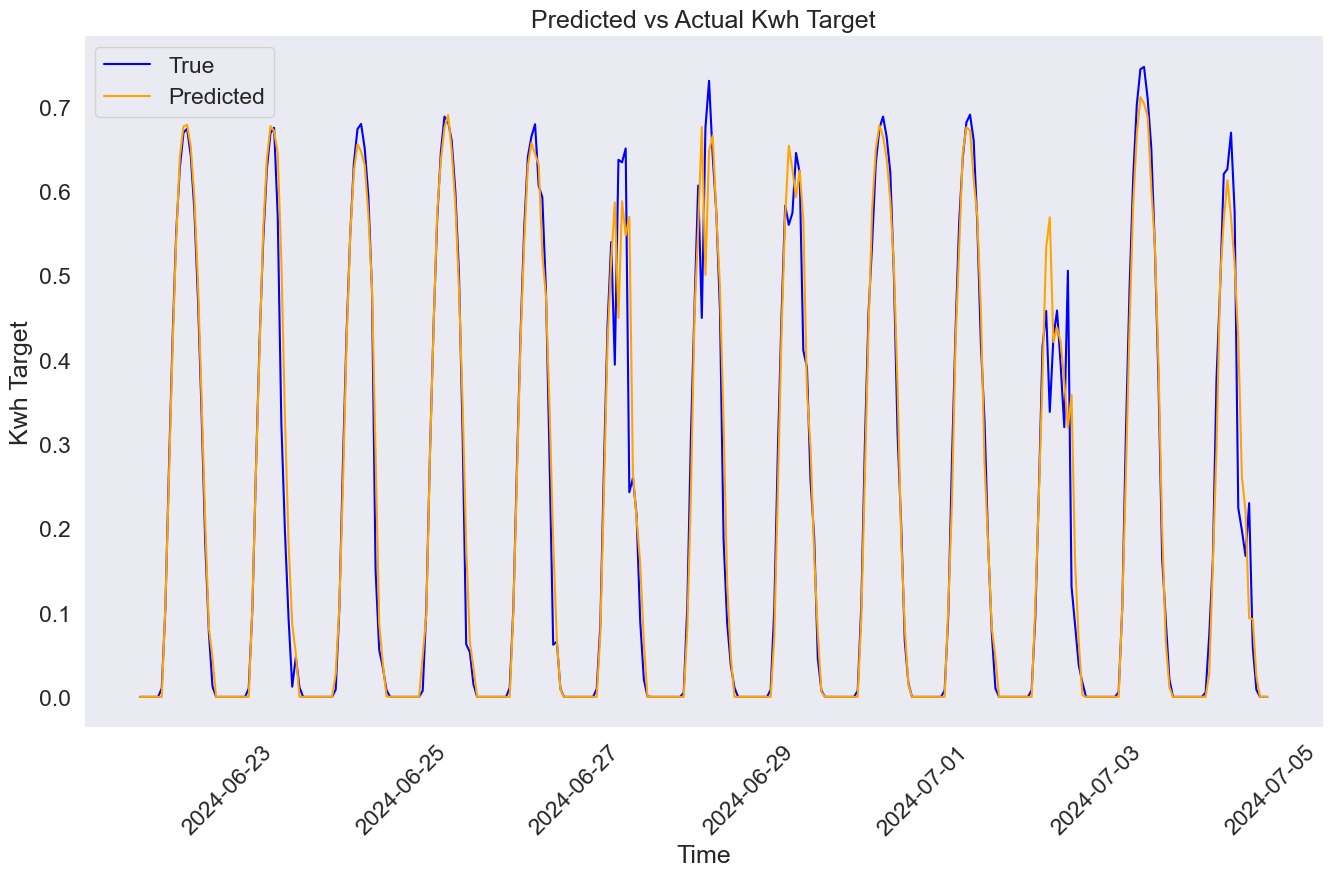

In [30]:
last_312_df = results_df.tail(312)


plt.figure(figsize=(16, 9))
sns.set_style('darkgrid')
sns.lineplot(x=last_312_df.index, y=last_312_df['True'], label='True', color='blue')
sns.lineplot(x=last_312_df.index, y=last_312_df['Predicted'], label='Predicted', color='orange')
plt.xlabel('Time')
plt.ylabel('Kwh Target')
plt.title('Predicted vs Actual Kwh Target')
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()

$
\hspace{4cm} \textbf{Simple Dense Model} \hspace{2.5cm} \textbf{Model with Dropout(0.2)} \\
Time Delay = 5 \rightarrow \hspace{2cm} 0.944224 \hspace{5cm} 0.9460512 \\
Time Delay = 8 \rightarrow \hspace{2cm} 0.936704 \hspace{5cm} 0.9483161 \\ 
Time Delay = 12 \rightarrow \hspace{1.85cm} 0.949178 \hspace{5cm} 0.9506539 \\
Time Delay = 16 \rightarrow \hspace{1.85cm} 0.949806 \hspace{5cm} 0.9503922 \\
Time Delay = 24 \rightarrow \hspace{1.85cm} 0.946911 \hspace{5cm} 0.9418904
$

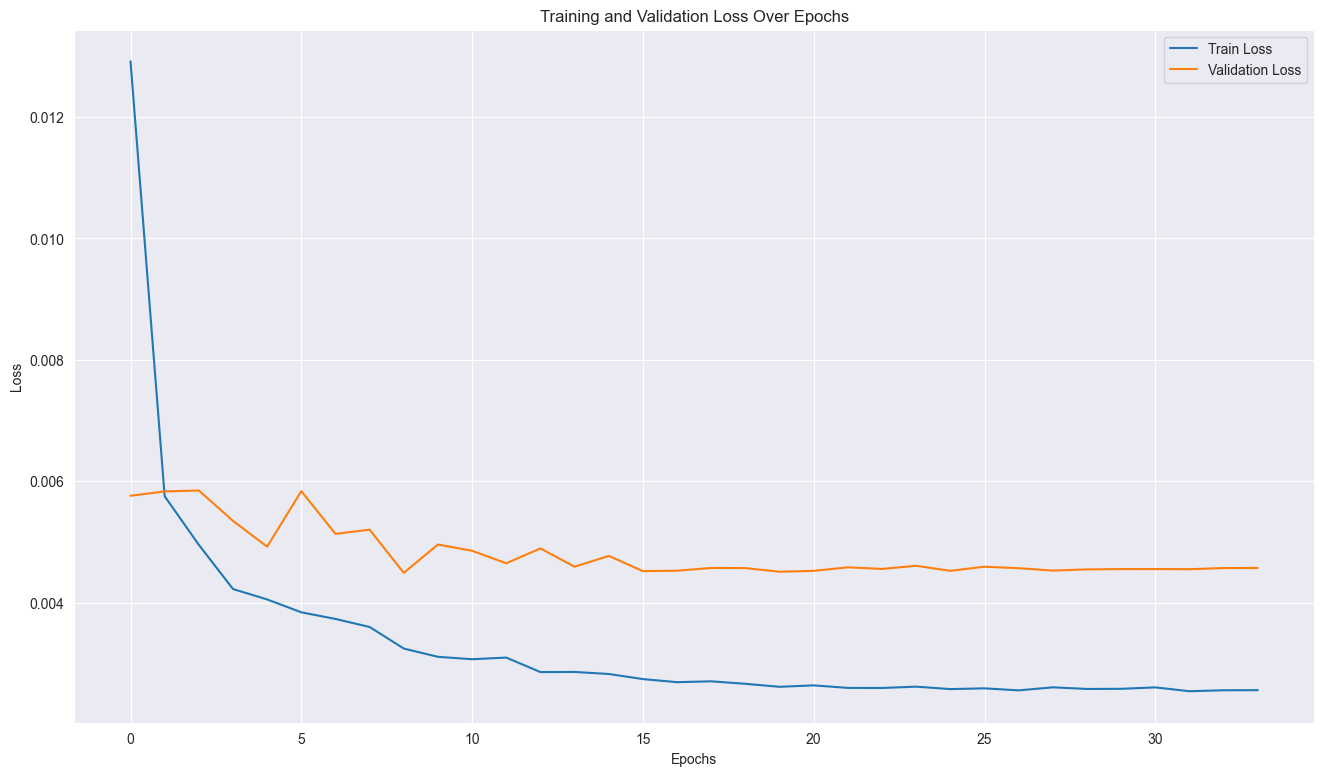

In [25]:
plt.figure(figsize = (16, 9))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.show()

<Axes: >

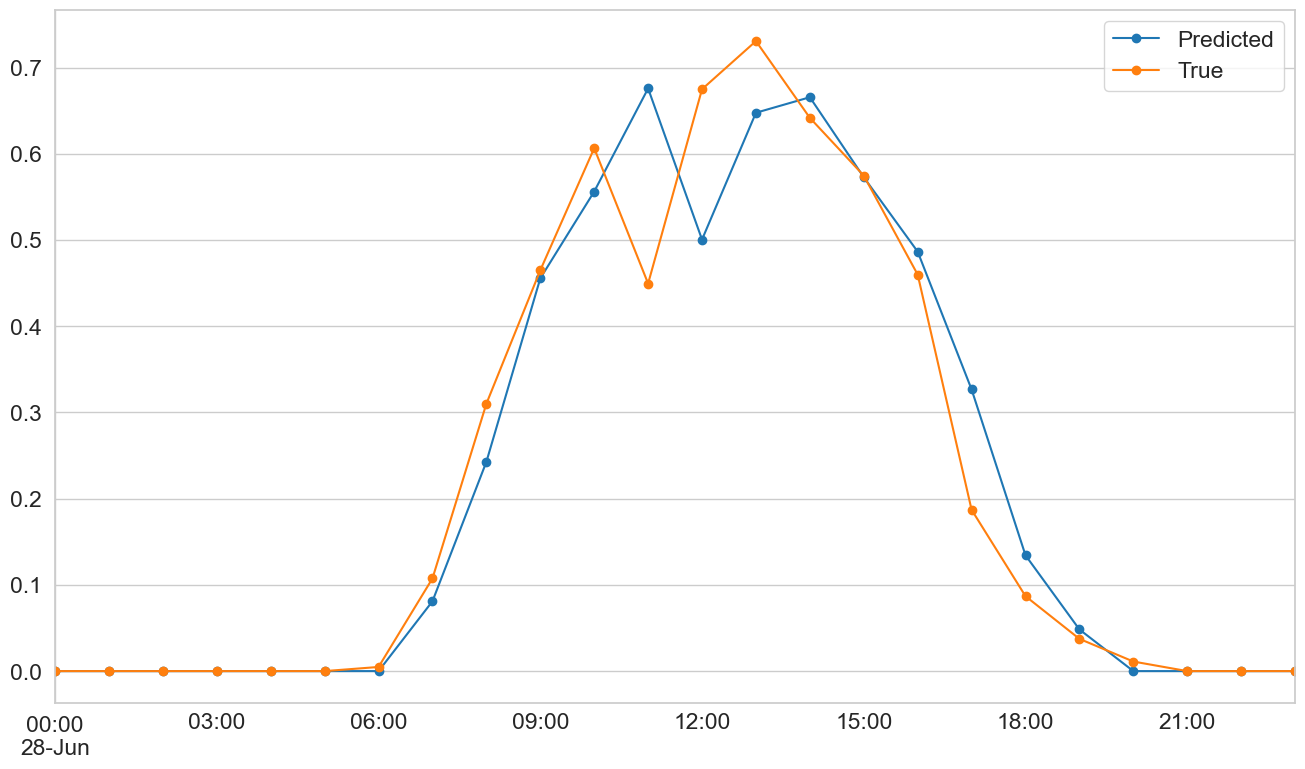

In [31]:
sns.set_context("notebook", font_scale=1.5)
sns.set_style("whitegrid")
results_df[-168: - 144].plot(figsize=(16, 9), marker = 'o')

In [28]:
mean_squared_error(results_df[-168: - 144]['Predicted'], results_df[-168: - 144]['True'])

0.00517367789720699

In [29]:
r2_score(results_df[-168: - 144]['Predicted'], results_df[-168: - 144]['True'])

0.919792951694826

<Axes: >

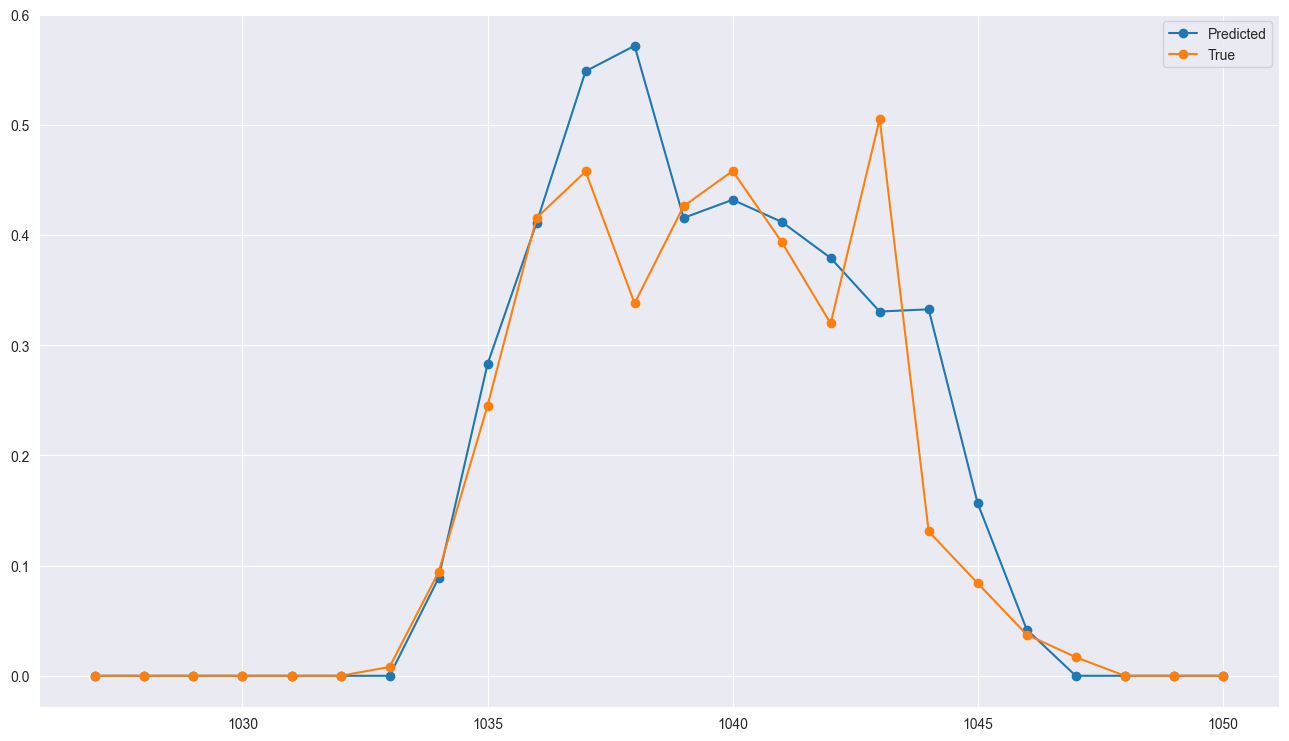

In [30]:
results_df[-72: -48].plot(figsize= (16, 9), marker = "o")

In [31]:
mean_squared_error(results_df[-72: -48]['Predicted'], results_df[-72: -48]['True'])

0.0060796526514078604

In [32]:
r2_score(results_df[-72: -48]['Predicted'], results_df[-72: -48]['True'])

0.8535022234368009

<Axes: >

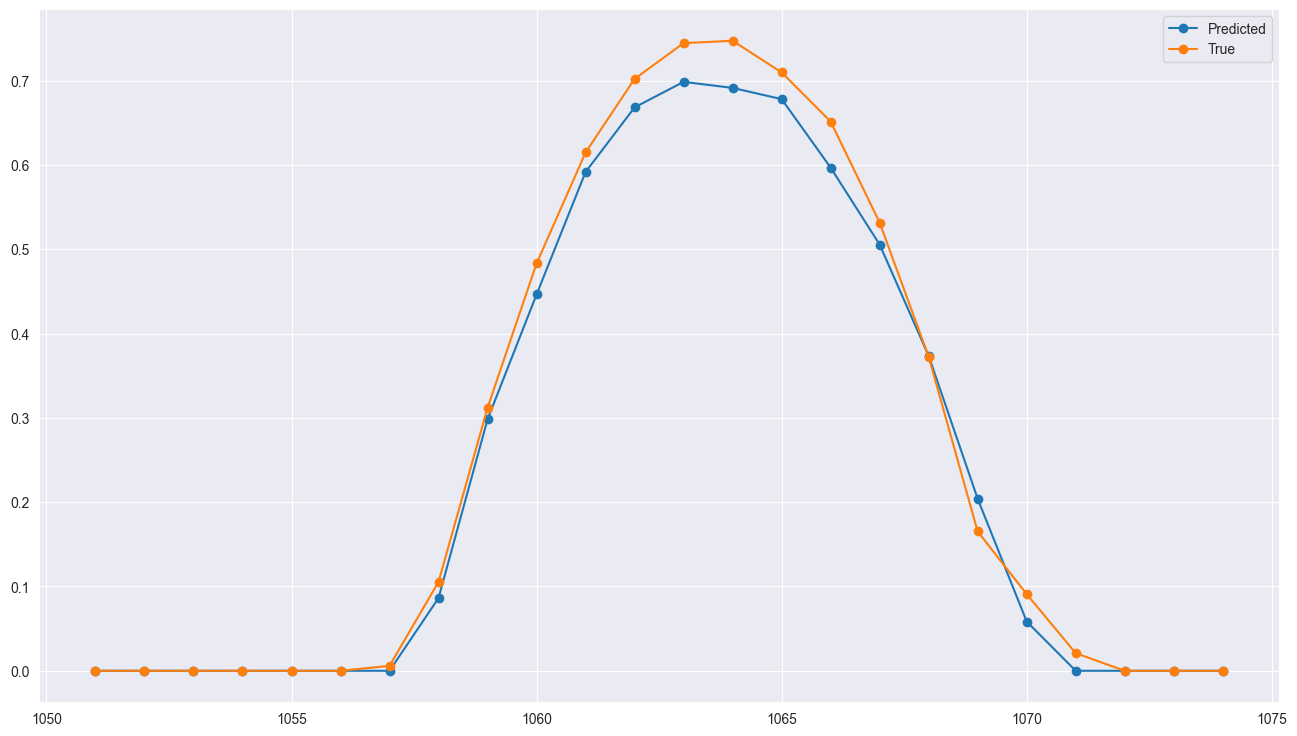

In [33]:
results_df[-48: -24].plot(figsize= (16, 9), marker = "o")